# Introduction

You work for the OilyGiant mining company. Your task is to find the best place for a new well.

Steps to choose the location:

Collect the oil well parameters in the selected region: oil quality and volume of reserves;
Build a model for predicting the volume of reserves in the new wells;
Pick the oil wells with the highest estimated values;
Pick the region with the highest total profit for the selected oil wells.
You have data on oil samples from three regions. Parameters of each oil well in the region are already known. Build a model that will help to pick the region with the highest profit margin. Analyze potential profit and risks using the Bootstrapping technique.

Project instructions
Download and prepare the data. Explain the procedure.
Train and test the model for each region:
 2.1. Split the data into a training set and validation set at a ratio of 75:25.
 2.2. Train the model and make predictions for the validation set.
 2.3. Save the predictions and correct answers for the validation set.
 2.4. Print the average volume of predicted reserves and model RMSE.
 2.5. Analyze the results.
Prepare for profit calculation:
 3.1. Store all key values for calculations in separate variables.
 3.2. Calculate the volume of reserves sufficient for developing a new well without losses. Compare the obtained value with the average volume of reserves in each region.
 3.3. Provide the findings about the preparation for profit calculation step.
Write a function to calculate profit from a set of selected oil wells and model predictions:
 4.1. Pick the wells with the highest values of predictions. 
 4.2. Summarize the target volume of reserves in accordance with these predictions
 4.3. Provide findings: suggest a region for oil wells' development and justify the choice. Calculate the profit for the obtained volume of reserves.
Calculate risks and profit for each region:
     5.1. Use the bootstrapping technique with 1000 samples to find the distribution of profit.
     5.2. Find average profit, 95% confidence interval and risk of losses. Loss is negative profit, calculate it as a probability and then express as a percentage.
     5.3. Provide findings: suggest a region for development of oil wells and justify the choice.
Data description
Geological exploration data for the three regions are stored in files:

geo_data_0.csv. download dataset
geo_data_1.csv. download dataset
geo_data_2.csv. download dataset
id — unique oil well identifier
f0, f1, f2 — three features of points (their specific meaning is unimportant, but the features themselves are significant)
product — volume of reserves in the oil well (thousand barrels).
Conditions:

Only linear regression is suitable for model training (the rest are not sufficiently predictable).
When exploring the region, a study of 500 points is carried with picking the best 200 points for the profit calculation.
The budget for development of 200 oil wells is 100 USD million.
One barrel of raw materials brings 4.5 USD of revenue The revenue from one unit of product is 4,500 dollars (volume of reserves is in thousand barrels).
After the risk evaluation, keep only the regions with the risk of losses lower than 2.5%. From the ones that fit the criteria, the region with the highest average profit should be selected.
The data is synthetic: contract details and well characteristics are not disclosed.

## Importing libraries and components

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Loading in Data

In [2]:
# Loading data

gd0 = pd.read_csv('datasets/geo_data_0.csv')
gd1 = pd.read_csv('datasets/geo_data_1.csv')
gd2 = pd.read_csv('datasets/geo_data_2.csv')

In [3]:
# Checking the data
display(gd0.info())
display(gd0.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


None

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


In [4]:
display(gd1.info())
display(gd1.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


None

,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305


In [5]:
display(gd2.info())
display(gd2.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


None

,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746


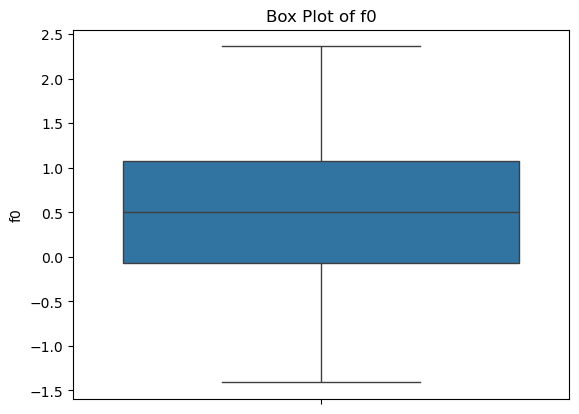

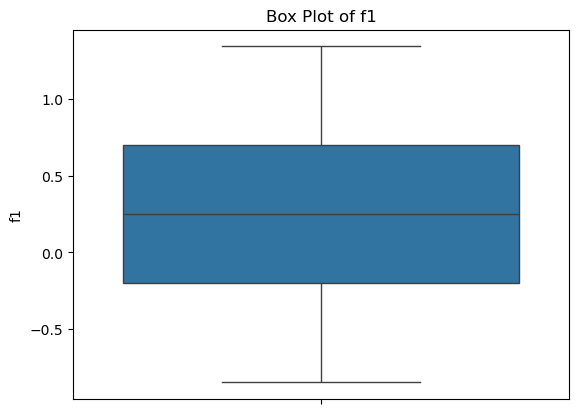

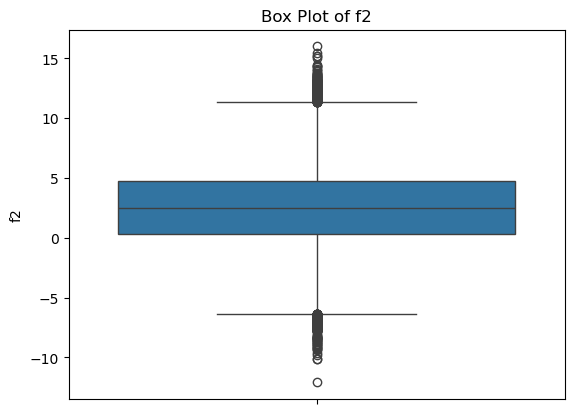

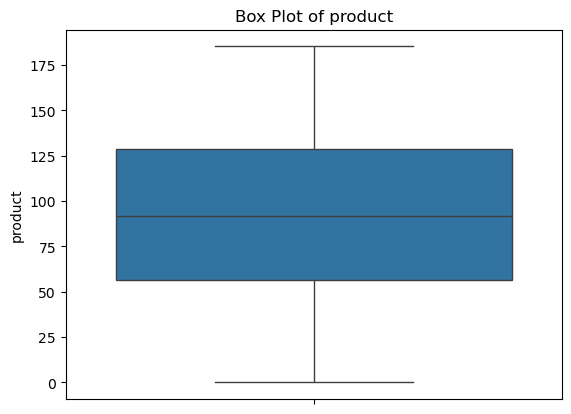

In [6]:
# Further checking the data.
for column in gd0.select_dtypes(include=['number']).columns:
    sns.boxplot(data=gd0[column])
    plt.title(f"Box Plot of {column}")
    plt.show()

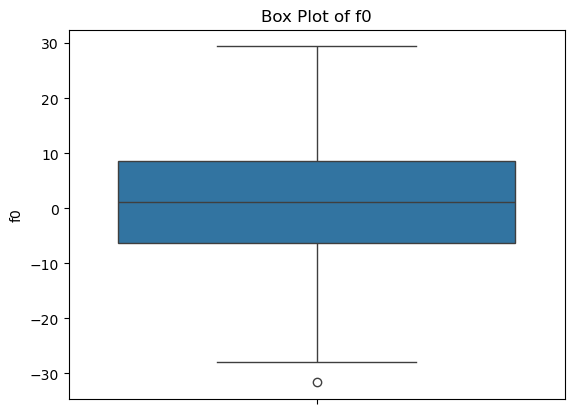

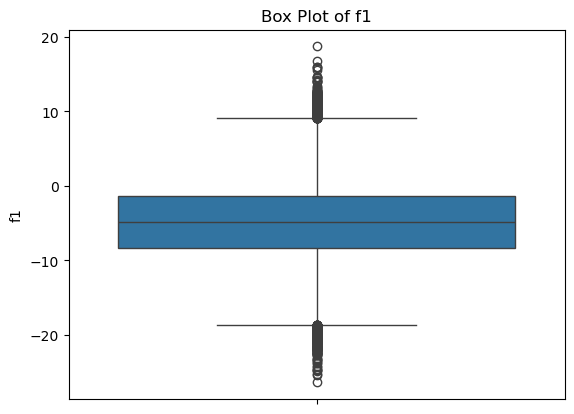

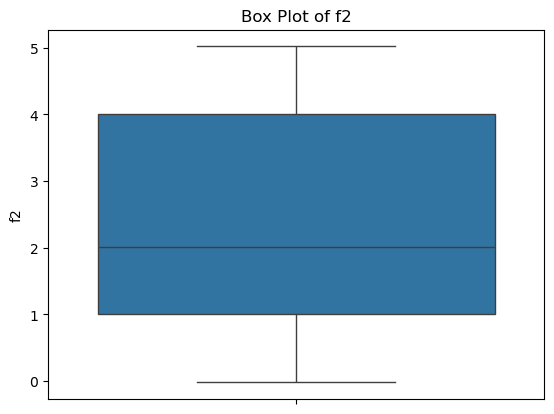

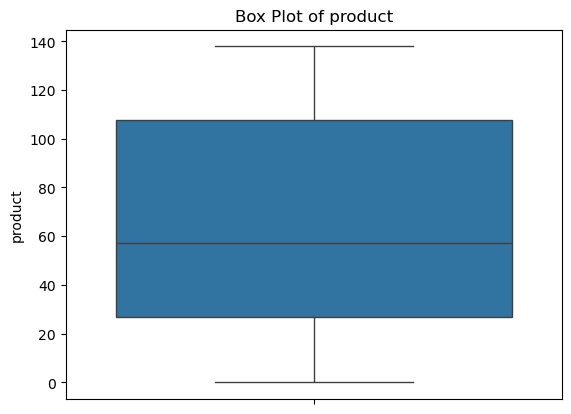

In [7]:
for column in gd1.select_dtypes(include=['number']).columns:
    sns.boxplot(data=gd1[column])
    plt.title(f"Box Plot of {column}")
    plt.show()

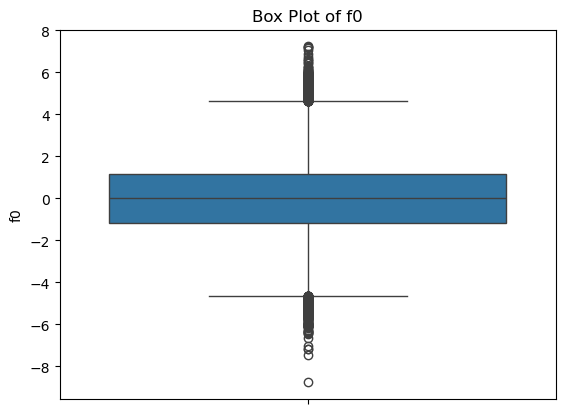

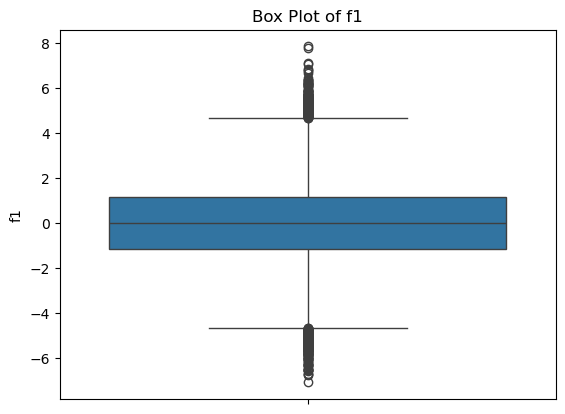

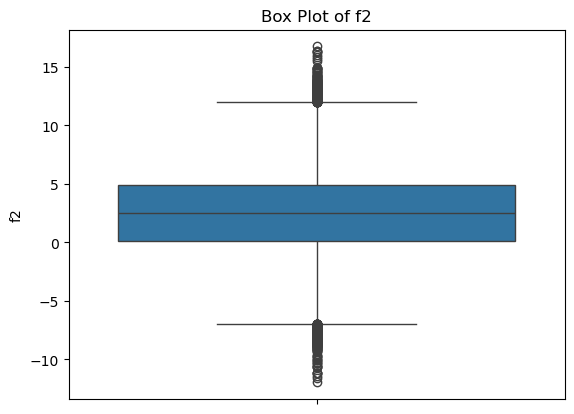

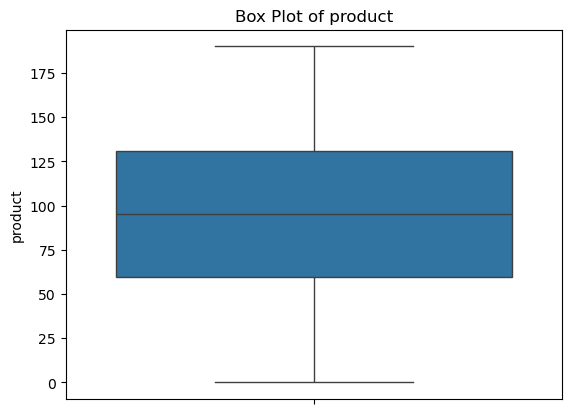

In [8]:
for column in gd2.select_dtypes(include=['number']).columns:
    sns.boxplot(data=gd2[column])
    plt.title(f"Box Plot of {column}")
    plt.show()

The ranges for f0, f1, and f2 vary wildly. Since I do not know what they are nor do I know if they are even the same variable across all three data sets I will leave them as is and not try to normalize them in any way. If it turns out I need to come back after building the models and checking the regression, I will do so. Additionally I am dropping all three ID columns since they are gibberesh and I can't do anything with them.

In [9]:
# Checking for duplicates
print(gd0.duplicated().sum())
print(gd1.duplicated().sum())
print(gd2.duplicated().sum())

0
0
0


In [10]:
# Dropping ID columns from the 3 data frames.
gd0 = gd0.drop(columns=['id'])
gd1 = gd1.drop(columns=['id'])
gd2 = gd2.drop(columns=['id'])

display(gd0, gd1, gd2)

,f0,f1,f2,product
0,0.705745,-0.497823,1.221170,105.280062
1,1.334711,-0.340164,4.365080,73.037750
2,1.022732,0.151990,1.419926,85.265647
3,-0.032172,0.139033,2.978566,168.620776
4,1.988431,0.155413,4.751769,154.036647
...,...,...,...,...
99995,0.971957,0.370953,6.075346,110.744026
99996,1.392429,-0.382606,1.273912,122.346843
99997,1.029585,0.018787,-1.348308,64.375443
99998,0.998163,-0.528582,1.583869,74.040764


,f0,f1,f2,product
0,-15.001348,-8.276000,-0.005876,3.179103
1,14.272088,-3.475083,0.999183,26.953261
2,6.263187,-5.948386,5.001160,134.766305
3,-13.081196,-11.506057,4.999415,137.945408
4,12.702195,-8.147433,5.004363,134.766305
...,...,...,...,...
99995,9.535637,-6.878139,1.998296,53.906522
99996,-10.160631,-12.558096,5.005581,137.945408
99997,-7.378891,-3.084104,4.998651,137.945408
99998,0.665714,-6.152593,1.000146,30.132364


,f0,f1,f2,product
0,-1.146987,0.963328,-0.828965,27.758673
1,0.262778,0.269839,-2.530187,56.069697
2,0.194587,0.289035,-5.586433,62.871910
3,2.236060,-0.553760,0.930038,114.572842
4,-0.515993,1.716266,5.899011,149.600746
...,...,...,...,...
99995,-1.777037,1.125220,6.263374,172.327046
99996,-1.261523,-0.894828,2.524545,138.748846
99997,-1.199934,-2.957637,5.219411,157.080080
99998,-2.419896,2.417221,-5.548444,51.795253


In [11]:
print("\nRegion 0 stats:")
print(gd0['product'].describe())
print("\nRegion 1 stats:")
print(gd1['product'].describe())
print("\nRegion 2 stats:")
print(gd2['product'].describe())

print("\nMissing values check:")
print("Region 0:", gd0['product'].isnull().sum())
print("Region 1:", gd1['product'].isnull().sum())
print("Region 2:", gd2['product'].isnull().sum())


Region 0 stats:
count    100000.000000
mean         92.500000
std          44.288691
min           0.000000
25%          56.497507
50%          91.849972
75%         128.564089
max         185.364347
Name: product, dtype: float64

Region 1 stats:
count    100000.000000
mean         68.825000
std          45.944423
min           0.000000
25%          26.953261
50%          57.085625
75%         107.813044
max         137.945408
Name: product, dtype: float64

Region 2 stats:
count    100000.000000
mean         95.000000
std          44.749921
min           0.000000
25%          59.450441
50%          94.925613
75%         130.595027
max         190.029838
Name: product, dtype: float64

Missing values check:
Region 0: 0
Region 1: 0
Region 2: 0


In [12]:
# Checking for duplicates
print(gd0.duplicated().sum())
print(gd1.duplicated().sum())
print(gd2.duplicated().sum())

0
0
0


## Train and test the model for each region

In [13]:
# Region 0
# Define Featuers and targets
features0 = gd0.drop(columns=['product'])
target0 = gd0['product']

# Split the data
features_train0, features_test0, target_train0, target_test0 = train_test_split(features0, target0, test_size=0.25, random_state=12345)

# Setting up a Linear Regression Model
model0 = LinearRegression()# initialize model constructor
model0.fit(features_train0, target_train0) # train model on training set
predictions0 = model0.predict(features0)

result0 = np.sqrt(mean_squared_error(target0, predictions0))# calculate RMSE on validation set
print("Predictions:", predictions0)
print("Average of predictions:", predictions0.mean())
print("RMSE of the linear regression model on the validation set:", result0)
gd0_results={'true_values': target0, 'predictions': predictions0}
gd0_prod_pred = target0.to_frame()
gd0_prod_pred['predictions'] = predictions0 

Predictions: [ 95.46197349 116.22739374  88.75025386 ...  72.40133961  99.3375482
 125.68476236]
Average of predictions: 92.6284927608878
RMSE of the linear regression model on the validation set: 37.69240596744536


In [14]:
# Region 1
# Define Featuers and targets
features1 = gd1.drop(columns=['product'])
target1 = gd1['product']

# Split the data
features_train1, features_test1, target_train1, target_test1 = train_test_split(features1, target1, test_size=0.25, random_state=12345)

# Setting up a Linear Regression Model
model1 = LinearRegression()# initialize model constructor
model1.fit(features_train1, target_train1) # train model on training set
predictions1 = model1.predict(features1)

result1 = np.sqrt(mean_squared_error(target1, predictions1))# calculate RMSE on validation set
print("Predictions:", predictions1)
print("Average of predictions:", predictions1.mean())
print("RMSE of the linear regression model on the validation set:", result1)
gd1_results={'true_values': target1, 'predictions': predictions1}
gd1_prod_pred = target1.to_frame()
gd1_prod_pred['predictions'] = predictions1 

Predictions: [  3.85353028  26.59237604 135.66569127 ... 137.51225781  28.64944732
   2.23466342]
Average of predictions: 68.82635271777153
RMSE of the linear regression model on the validation set: 0.890380265029757


In [15]:
# Region 2
# Define Featuers and targets
features2 = gd2.drop(columns=['product'])
target2 = gd2['product']

# Split the data
features_train2, features_test2, target_train2, target_test2 = train_test_split(features2, target2, test_size=0.25, random_state=12345)

# Setting up a Linear Regression Model
model2 = LinearRegression()# initialize model constructor
model2.fit(features_train2, target_train2) # train model on training set
predictions2 = model2.predict(features2)

result2 = np.sqrt(mean_squared_error(target2, predictions2))# calculate RMSE on validation set
print("Predictions:", predictions2)
print("Average of predictions:", predictions2.mean())
print("RMSE of the linear regression model on the validation set:", result2)
gd2_results={'true_values': target2, 'predictions': predictions2}
gd2_prod_pred = target2.to_frame()
gd2_prod_pred['predictions'] = predictions2 

Predictions: [ 75.96850616  66.32966397  48.88003914 ... 110.65847775  48.92689674
 115.55251712]
Average of predictions: 95.02020328978766
RMSE of the linear regression model on the validation set: 40.055624818752136


Region 0 and Region 2 have higher predictions than 1. However, the RMSE for both are wildly higher than the RMSE of region 1. This means I either botched it like crazy or that the potentials maybe higher in 0 and 2 but the risk of variance of insanely higher. This might throw off the expected rate of returns.

## Profit Calculations

In [16]:
# Stating variables
FIXED_COST = 100000000
COST_PER_WELL = FIXED_COST / 200
REVENUE_PER_UNIT = 4.5 * 1000

In [17]:
# Breakeven calculation

break_even_units = COST_PER_WELL / REVENUE_PER_UNIT
display(break_even_units)

111.11111111111111

In [18]:
# Comparing average reserves to break even.
avg_reserves0 = gd0_prod_pred['product'].mean()
avg_reserves1 = gd1_prod_pred['product'].mean()
avg_reserves2 = gd2_prod_pred['product'].mean()
display(f"Region 0 average: {avg_reserves0} units. Minus breakeven: {avg_reserves0 - break_even_units}, or ${(avg_reserves0 - break_even_units)*REVENUE_PER_UNIT}")
display(f"Region 1 average: {avg_reserves1} units. Minus breakeven: {avg_reserves1 - break_even_units}, or ${(avg_reserves1 - break_even_units)*REVENUE_PER_UNIT}")
display(f"Region 2 average: {avg_reserves2} units. Minus breakeven: {avg_reserves2 - break_even_units}, or ${(avg_reserves2 - break_even_units)*REVENUE_PER_UNIT}")

'Region 0 average: 92.5 units. Minus breakeven: -18.611111111111114, or $-83750.00000000001'

'Region 1 average: 68.825 units. Minus breakeven: -42.28611111111111, or $-190287.5'

'Region 2 average: 95.0 units. Minus breakeven: -16.111111111111114, or $-72500.00000000001'

If we are just looking at the raw average of each region, there is an expected loss ranging from approx. $72500 to 190000. so if we were to blindly pick from each region we are looking at a slight loss.

In [19]:
# Comparing average product to predictions
avg_pred0 = gd0_prod_pred['predictions'].mean()
avg_pred1 = gd1_prod_pred['predictions'].mean()
avg_pred2 = gd2_prod_pred['predictions'].mean()
display(f"Region 0 average: {avg_reserves0} units. Predictions average minus actual average: {avg_pred0-avg_reserves0}")
display(f"Region 1 average: {avg_reserves1} units. Predictions average minus actual average: {avg_pred1-avg_reserves1}")
display(f"Region 2 average: {avg_reserves2} units. Predictions average minus actual average: {avg_pred2-avg_reserves2}")

'Region 0 average: 92.5 units. Predictions average minus actual average: 0.12849276088779504'

'Region 1 average: 68.825 units. Predictions average minus actual average: 0.0013527177715246808'

'Region 2 average: 95.0 units. Predictions average minus actual average: 0.020203289787659173'

## Profit/loss from selected wells.

In [20]:
# Function for calculating profit/loss
def profit_loss(production):
    profit = (production * REVENUE_PER_UNIT) - FIXED_COST
    return profit

## Calculate risks and profit for each region

In [21]:
# Bootstrapping each region for confidence intveral

def bootstrap_profit(selected_wells, n_samples):
    
    profits = []
    state = np.random.RandomState(12345)
    
    for _ in range(n_samples):
        # Random sample with replacement
        sample = selected_wells.sample(n=500, replace=True, random_state=state)
        # Sorting and getting the top 200
        sample_sorted = sample.sort_values(by='predictions', ascending=False)
        sample_200 = sample_sorted.head(200)
        # Calculate total production
        total_production = sample_200['product'].sum()
        # Calculate profit (production * price - cost)
        profit = profit_loss(total_production)
        profits.append(profit)
    return profits



In [22]:
# Region 0
profits0 = bootstrap_profit(gd0_prod_pred, 1000)

In [23]:
# Region 1
profits1 = bootstrap_profit(gd1_prod_pred, 1000)

In [24]:
# Region 2
profits2 = bootstrap_profit(gd2_prod_pred, 1000)

In [25]:
# 95% confidence interval
def bootstrap_results(profits):
    # Average profit
    avg_profit = np.mean(profits)
    
    # 95% confidence interval
    confidence_interval = np.percentile(profits, [2.5, 97.5])
    
    # Risk of losses
    negative_profits = sum(profit < 0 for profit in profits)
    risk_percentage = negative_profits/len(profits)
    
    return avg_profit, confidence_interval, risk_percentage

In [26]:
# Region 0 
avg_profit0, confidence_interval0, risk_percentage0 = bootstrap_results(profits0)
print(f"The average_profit is ${avg_profit0}. Confidence interval is {confidence_interval0}. And has a risk percentage of {risk_percentage0} for region 0.")

The average_profit is $4241497.51404505. Confidence interval is [-778569.23734889 9685806.99598609]. And has a risk percentage of 0.052 for region 0.


In [27]:
# Region 1 
avg_profit1, confidence_interval1, risk_percentage1 = bootstrap_results(profits1)
print(f"The average_profit is ${avg_profit1}. Confidence interval is {confidence_interval1}. And has a risk percentage of {risk_percentage1} for region 1.")

The average_profit is $4487206.400344507. Confidence interval is [ 374980.74533962 8238299.20208387]. And has a risk percentage of 0.014 for region 1.


In [28]:
# Region 2
avg_profit2, confidence_interval2, risk_percentage2 = bootstrap_results(profits2)
print(f"The average_profit is ${avg_profit2}. Confidence interval is {confidence_interval2}. And has a risk percentage of {risk_percentage2} for region 2.")

The average_profit is $3739390.2198985177. Confidence interval is [-1819481.8844712   8962994.08100872]. And has a risk percentage of 0.092 for region 2.


## Conclusion

Based off the last set of results, region 1 performed best in the predictions. The estimated average of $4487206.40 with a range from $374980.74 to $8238299.20 confidence interval at 95% confidence level. It also coincedentally has the lowest risk percentage at 1.4%. althought it does not have the highest in thThis performed the best overall based on analysis and is recommended as the best region for our investments.